# Understanding How LSTMs, Transformers, and SSMs Scale with Sequence Length

This notebook compares a multi-layer LSTM, a Transformer encoder, and a simplified Mamba-style State Space Model on a Needle-in-a-Haystack retrieval task. The experiment measures retrieval accuracy, loss/perplexity, training time, and memory usage for sequence lengths 32, 64, 128, 256, 512, and 1024.


In [2]:
!pip install causal-conv1d --no-build-isolation
!pip install mamba-ssm --no-build-isolation

  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.8 MB/s eta 0:00:00
  Created wheel for causal-conv1d: filename=causal_conv1d-1.6.2.post1-cp312-cp312-linux_x86_64.whl size=171314356 sha256=4f188f5527a6f1a6e8fe4bc078f4a94337ae2bbaf0951b635835833ffe6410ac
  Stored in directory: /root/.cache/pip/wheels/ea/f0/26/5d87ae05a302e6dc8016c50cd8c7ee779585f593b9580e7cf8
Successfully built causal-conv1d
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 51.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.7/338.7 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 MB 8.1 MB/s eta 0:00:00:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 66.4 MB/s eta 0:00

In [3]:
from mamba_ssm import Mamba

print("✅ Mamba imported successfully!")

✅ Mamba imported successfully!


In [4]:
!pip show mamba-ssm

Name: mamba_ssm
Version: 2.3.2.post1
Summary: Mamba state-space model
Home-page: https://github.com/state-spaces/mamba
Author: Tri Dao, Albert Gu
Author-email: Tri Dao <tri@tridao.me>, Albert Gu <agu@cs.cmu.edu>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
    

In [5]:
import sys
print(sys.executable)

/usr/bin/python3


In [6]:
!{sys.executable} -m pip show mamba-ssm

Name: mamba_ssm
Version: 2.3.2.post1
Summary: Mamba state-space model
Home-page: https://github.com/state-spaces/mamba
Author: Tri Dao, Albert Gu
Author-email: Tri Dao <tri@tridao.me>, Albert Gu <agu@cs.cmu.edu>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
    

In [7]:
import json
import math
import os
import random
import resource
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(".cache").resolve()))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

USE_AMP = DEVICE.type == "cuda"

from mamba_ssm import Mamba

MAMBA_BACKEND = "official mamba-ssm"

print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))
print(f"AMP enabled: {USE_AMP}")
print(f"Mamba backend: {MAMBA_BACKEND}")


Using device: cuda
NVIDIA L4
AMP enabled: True
Mamba backend: official mamba-ssm


In [8]:
  import sys, torch, os
  print(sys.executable)
  print(torch.cuda.is_available())
  print(torch.version.cuda)

/usr/bin/python3
True
12.8


In [9]:
# Experiment settings from the proposal.
SEQ_LENGTHS = [32, 64, 128, 256, 512, 1024]
MODEL_NAMES = ["lstm", "transformer", "mamba"]
MAX_SEQ_LEN_BY_MODEL = {
    "lstm": 1024,
    "transformer": 1024,
    "mamba": 1024,
}
VOCAB_SIZE = 64
PAD_TOKEN = 0
NEEDLE_TOKEN = 1
QUERY_TOKEN = 2
VALUE_OFFSET = 3
NUM_VALUE_CLASSES = 10

BATCH_SIZE = 64
TRAIN_SAMPLES = 2048
VAL_SAMPLES = 512
EPOCHS_BY_LENGTH = {
    32: 8,
    64: 10,
    128: 12,
    256: 14,
    512: 16,
    1024: 16,
}
LEARNING_RATE = 3e-4
RESULTS_PATH = Path("results.json")
EXPERIMENT_SCHEMA = "needle_retrieval_v2"


## Needle-in-a-Haystack Dataset

Each sequence contains one `NEEDLE_TOKEN`. The token after the needle is a value token, and the final `QUERY_TOKEN` asks the model to retrieve that hidden value. The target is the value class, so accuracy directly measures retrieval ability.


In [10]:
class NeedleRetrievalDataset(Dataset):
    def __init__(self, seq_len, n_samples, vocab_size=VOCAB_SIZE, seed=SEED):
        if seq_len < 4:
            raise ValueError("seq_len must be at least 4")
        self.seq_len = seq_len
        self.n_samples = n_samples
        self.vocab_size = vocab_size
        self.seed = seed + seq_len * 1_000_003 + n_samples

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        if idx >= self.n_samples:
            raise IndexError("out of range")

        generator = torch.Generator().manual_seed(self.seed + idx)
        seq = torch.randint(
            VALUE_OFFSET + NUM_VALUE_CLASSES,
            self.vocab_size,
            (self.seq_len,),
            generator=generator,
        )
        needle_pos = torch.randint(0, self.seq_len - 2, (1,), generator=generator).item()
        value_class = torch.randint(0, NUM_VALUE_CLASSES, (1,), generator=generator).item()

        seq[needle_pos] = NEEDLE_TOKEN
        seq[needle_pos + 1] = VALUE_OFFSET + value_class
        seq[-1] = QUERY_TOKEN
        return seq.long(), torch.tensor(value_class, dtype=torch.long)


def make_loaders(seq_len):
    train_ds = NeedleRetrievalDataset(seq_len, TRAIN_SAMPLES, seed=SEED)
    val_ds = NeedleRetrievalDataset(seq_len, VAL_SAMPLES, seed=SEED + 10_000)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader

sample_x, sample_y = NeedleRetrievalDataset(32, 1)[0]
print(sample_x.tolist())
print("target value class:", sample_y.item())


[52, 44, 61, 18, 58, 35, 13, 26, 1, 3, 50, 50, 46, 42, 28, 27, 33, 51, 14, 63, 13, 60, 47, 17, 57, 13, 14, 27, 23, 52, 37, 2]
target value class: 0


## Models


In [11]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=64, hidden_dim=80, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_dim, NUM_VALUE_CLASSES)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])


class TransformerModel(nn.Module):
    def __init__(self, seq_len, vocab_size=VOCAB_SIZE, embed_dim=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.position = nn.Embedding(seq_len, embed_dim)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, NUM_VALUE_CLASSES)

    def forward(self, x):
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.embedding(x) + self.position(positions)
        out = self.encoder(x)
        return self.classifier(self.norm(out[:, -1, :]))


In [12]:
class MambaModel(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=80, d_state=16, d_conv=4, expand=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "norm": nn.LayerNorm(embed_dim),
                "mamba": Mamba(
                    d_model=embed_dim,
                    d_state=d_state,
                    d_conv=d_conv,
                    expand=expand,
                ),
            })
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, NUM_VALUE_CLASSES)

    def forward(self, x):
        x = self.embedding(x)
        for layer in self.layers:
            x = x + layer["mamba"](layer["norm"](x))
        return self.classifier(self.norm(x[:, -1, :]))


In [13]:
def build_model(model_name, seq_len):
    if model_name == "lstm":
        return LSTMModel()
    if model_name == "transformer":
        return TransformerModel(seq_len=seq_len)
    if model_name == "mamba":
        return MambaModel()
    raise ValueError(f"Unknown model: {model_name}")


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for name in MODEL_NAMES:
    model = build_model(name, seq_len=32)
    print(f"{name:12s} params: {count_params(model):,}")


lstm         params: 103,466
transformer  params: 106,890
mamba        params: 104,010


## Training and Evaluation


In [14]:
def reset_peak_memory():
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    elif DEVICE.type == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()
    return current_process_memory_mb()


def current_process_memory_mb():
    usage = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if os.name == "posix" and hasattr(os, "uname") and os.uname().sysname == "Darwin":
        return usage / (1024 ** 2)
    return usage / 1024


def peak_memory_mb():
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    if DEVICE.type == "mps" and hasattr(torch.mps, "current_allocated_memory"):
        return torch.mps.current_allocated_memory() / (1024 ** 2)
    return current_process_memory_mb()


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_count += y.size(0)

    avg_loss = total_loss / total_count
    return {
        "loss": avg_loss,
        "perplexity": math.exp(min(avg_loss, 20)),
        "accuracy": total_correct / total_count,
    }


def train_one_model(model_name, seq_len, epochs):
    train_loader, val_loader = make_loaders(seq_len)
    model = build_model(model_name, seq_len).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = {
        "schema": EXPERIMENT_SCHEMA,
        "model": model_name,
        "seq_len": seq_len,
        "train_loss": [],
        "val_loss": [],
        "perplexity": [],
        "accuracy": [],
        "time": [],
        "memory_mb": [],
        "params": count_params(model),
    }

    for epoch in range(1, epochs + 1):
        model.train()
        baseline_memory = reset_peak_memory()
        start = time.perf_counter()
        train_loss = 0.0
        train_count = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(x)
                loss = F.cross_entropy(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * y.size(0)
            train_count += y.size(0)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss / train_count)
        history["val_loss"].append(metrics["loss"])
        history["perplexity"].append(metrics["perplexity"])
        history["accuracy"].append(metrics["accuracy"])
        history["time"].append(elapsed)
        history["memory_mb"].append(max(peak_memory_mb(), baseline_memory))

        memory_text = "n/a" if history["memory_mb"][-1] is None else f"{history['memory_mb'][-1]:.1f}MB"
        print(
            f"{model_name:12s} L={seq_len:4d} epoch={epoch:02d}/{epochs} "
            f"acc={metrics['accuracy']:.3f} ppl={metrics['perplexity']:.2f} "
            f"time={elapsed:.1f}s mem={memory_text}"
        )

    return history


In [15]:
def load_results():
    if not RESULTS_PATH.exists() or RESULTS_PATH.stat().st_size == 0:
        return {}
    try:
        raw_results = json.loads(RESULTS_PATH.read_text())
    except json.JSONDecodeError:
        print(f"Ignoring unreadable results file: {RESULTS_PATH}")
        return {}
    return {
        key: value
        for key, value in raw_results.items()
        if isinstance(value, dict) and value.get("schema") == EXPERIMENT_SCHEMA
    }


def save_results(results):
    existing = {}
    if RESULTS_PATH.exists() and RESULTS_PATH.stat().st_size > 0:
        try:
            existing = json.loads(RESULTS_PATH.read_text())
        except json.JSONDecodeError:
            existing = {}
    existing.update(results)
    temp_path = RESULTS_PATH.with_suffix(".tmp")
    temp_path.write_text(json.dumps(existing, indent=2))
    os.replace(temp_path, RESULTS_PATH)


def is_complete_result(run, epochs):
    required = ["accuracy", "perplexity", "time", "memory_mb", "train_loss", "val_loss"]
    return (
        run.get("schema") == EXPERIMENT_SCHEMA
        and all(metric in run for metric in required)
        and len(run.get("accuracy", [])) >= epochs
    )


def max_seq_len_for_model(model_name):
    return MAX_SEQ_LEN_BY_MODEL.get(model_name, max(SEQ_LENGTHS))


def run_experiment(skip_completed=True):
    results = load_results()
    for seq_len in SEQ_LENGTHS:
        print("=" * 70)
        print(f"Sequence length: {seq_len}")
        print("=" * 70)
        for model_name in MODEL_NAMES:
            model_max_len = max_seq_len_for_model(model_name)
            if seq_len > model_max_len:
                print(f"Skipping {model_name}_{seq_len}; configured max length is {model_max_len}")
                continue
            key = f"{model_name}_{seq_len}"
            epochs = EPOCHS_BY_LENGTH[seq_len]
            if skip_completed and key in results and is_complete_result(results[key], epochs):
                print(f"Skipping {key}; already has {len(results[key]['accuracy'])} compatible epochs")
                continue
            results[key] = train_one_model(model_name, seq_len, epochs)
            save_results(results)
    return results

# Run this cell to execute the study. Official mamba-ssm runs to 1024.
results = run_experiment(skip_completed=True)



Sequence length: 32
lstm         L=  32 epoch=01/8 acc=0.100 ppl=10.04 time=1.1s mem=1100.5MB
lstm         L=  32 epoch=02/8 acc=0.109 ppl=10.01 time=0.2s mem=1746.5MB
lstm         L=  32 epoch=03/8 acc=0.113 ppl=9.96 time=0.2s mem=1746.6MB
lstm         L=  32 epoch=04/8 acc=0.141 ppl=9.87 time=0.2s mem=1746.6MB
lstm         L=  32 epoch=05/8 acc=0.211 ppl=9.53 time=0.2s mem=1746.6MB
lstm         L=  32 epoch=06/8 acc=0.367 ppl=6.46 time=0.2s mem=1746.6MB
lstm         L=  32 epoch=07/8 acc=0.717 ppl=2.73 time=0.2s mem=1746.6MB
lstm         L=  32 epoch=08/8 acc=0.930 ppl=1.58 time=0.2s mem=1746.6MB
transformer  L=  32 epoch=01/8 acc=0.129 ppl=9.83 time=0.4s mem=1747.2MB
transformer  L=  32 epoch=02/8 acc=0.357 ppl=8.69 time=0.3s mem=1799.2MB
transformer  L=  32 epoch=03/8 acc=0.615 ppl=4.44 time=0.3s mem=1799.3MB
transformer  L=  32 epoch=04/8 acc=0.957 ppl=1.63 time=0.3s mem=1799.3MB
transformer  L=  32 epoch=05/8 acc=1.000 ppl=1.13 time=0.3s mem=1799.3MB
transformer  L=  32 epoch=06/

## Summarize and Plot Results


lstm         L=  32 acc=0.930 ppl=1.58 time=0.2s mem=1746.6MB params=103,466
transformer  L=  32 acc=1.000 ppl=1.03 time=0.3s mem=1799.3MB params=106,890
mamba        L=  32 acc=0.549 ppl=3.78 time=0.3s mem=2279.5MB params=104,010
lstm         L=  64 acc=0.398 ppl=5.40 time=0.2s mem=2300.5MB params=103,466
transformer  L=  64 acc=1.000 ppl=1.04 time=0.3s mem=2301.0MB params=108,938
mamba        L=  64 acc=0.105 ppl=11.94 time=0.3s mem=2301.3MB params=104,010
lstm         L= 128 acc=0.107 ppl=10.60 time=0.2s mem=2301.7MB params=103,466
transformer  L= 128 acc=1.000 ppl=1.04 time=0.3s mem=2308.0MB params=113,034
mamba        L= 128 acc=0.115 ppl=12.15 time=0.4s mem=2308.2MB params=104,010
lstm         L= 256 acc=0.096 ppl=11.21 time=0.2s mem=2309.6MB params=103,466
transformer  L= 256 acc=0.932 ppl=1.22 time=0.3s mem=2310.0MB params=121,226
mamba        L= 256 acc=0.115 ppl=15.01 time=0.4s mem=2310.0MB params=104,010
lstm         L= 512 acc=0.100 ppl=11.40 time=0.3s mem=2310.1MB params=1

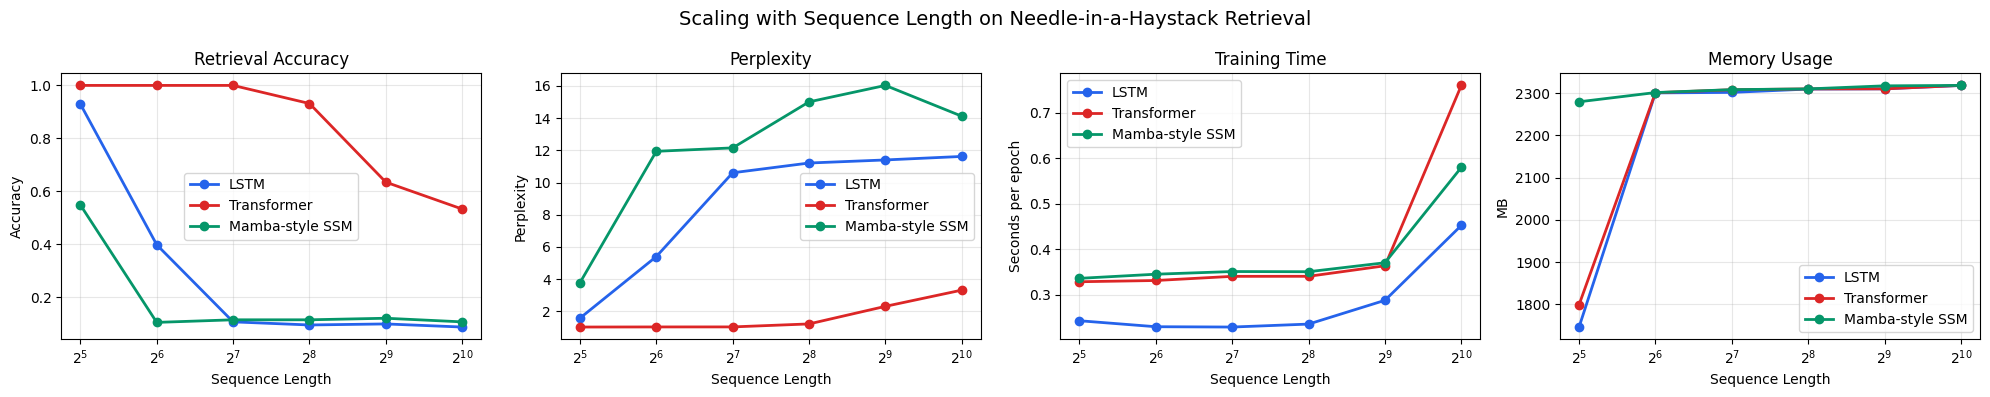

In [16]:
def summarize_results(results=None):
    if results is None:
        results = load_results()
    rows = []
    for seq_len in SEQ_LENGTHS:
        for model_name in MODEL_NAMES:
            run = results.get(f"{model_name}_{seq_len}")
            if not run or not run.get("accuracy"):
                continue
            rows.append({
                "model": model_name,
                "seq_len": seq_len,
                "params": run.get("params"),
                "accuracy": run["accuracy"][-1],
                "perplexity": run["perplexity"][-1],
                "sec_per_epoch": run["time"][-1],
                "memory_mb": run["memory_mb"][-1],
            })
    if not rows:
        print("No compatible results found. Run `results = run_experiment(skip_completed=True)` first.")
        return []
    for row in rows:
        print(
            f"{row['model']:12s} L={row['seq_len']:4d} "
            f"acc={row['accuracy']:.3f} ppl={row['perplexity']:.2f} "
            f"time={row['sec_per_epoch']:.1f}s mem={row['memory_mb']:.1f}MB "
            f"params={row['params']:,}"
        )
    return rows


def final_value(results, model_name, seq_len, metric):
    key = f"{model_name}_{seq_len}"
    values = results.get(key, {}).get(metric, [])
    if not values:
        return None
    return values[-1]


def plot_results(results=None):
    if results is None:
        results = load_results()
    if not results:
        print("No compatible results found. Run `results = run_experiment(skip_completed=True)` first.")
        return

    colors = {"lstm": "#2563eb", "transformer": "#dc2626", "mamba": "#059669"}
    labels = {"lstm": "LSTM", "transformer": "Transformer", "mamba": "Mamba-style SSM"}
    metric_specs = [
        ("accuracy", "Retrieval Accuracy", "Accuracy"),
        ("perplexity", "Perplexity", "Perplexity"),
        ("time", "Training Time", "Seconds per epoch"),
        ("memory_mb", "Memory Usage", "MB"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle("Scaling with Sequence Length on Needle-in-a-Haystack Retrieval", fontsize=14)

    for ax, (metric, title, ylabel) in zip(axes, metric_specs):
        for model_name in MODEL_NAMES:
            xs, ys = [], []
            for seq_len in SEQ_LENGTHS:
                value = final_value(results, model_name, seq_len, metric)
                if value is not None:
                    xs.append(seq_len)
                    ys.append(value)
            if xs:
                ax.plot(xs, ys, marker="o", linewidth=2, color=colors[model_name], label=labels[model_name])
        ax.set_title(title)
        ax.set_xlabel("Sequence Length")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log", base=2)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig("results_plot.png", dpi=150, bbox_inches="tight")
    plt.show()

results = load_results()
if results:
    summarize_results(results)
    plot_results(results)
else:
    print("No compatible results found. Run `results = run_experiment(skip_completed=True)` first.")
